In [1]:
!pip install -q -U transformers
!pip install -q -U accelerate # While not explicitly called out in your code, accelerate is often used by transformers for performance enhancements
!pip install -q beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 86.7 MB/s eta 0:00:00


In [2]:
# sentimental analysis usingpipeline
from transformers import pipeline
sentiment_pipeline = pipeline('sentiment-analysis') #sentimantal-analysis is one of HuggingFace's built-in pipeline tasks, and created an pipeline object
data = ['I love you','I hate you'] #String → one prediction , List → batch predictions
sentiment_pipeline(data)
#This is how the process look ---- So i need to build a specific model for the IMDB data

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998656511306763},
 {'label': 'NEGATIVE', 'score': 0.9991129040718079}]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/refs/heads/master/IMDB-Dataset.csv")
df = df.sample(10000,random_state = 42)
df.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [5]:
df.isnull().sum()
df["sentiment"].describe()

,sentiment
count,10000
unique,2
top,positive
freq,5039


In [6]:
df['word_count'] = df["review"].str.split().str.len() # str is used here because df["review"] is a pandas Series (a column), not a single string.
print(df['word_count'].describe())

count    10000.000000
mean       231.759000
std        170.274063
min          9.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       1316.000000
Name: word_count, dtype: float64


In [7]:
# df["review"] = df["review"].str.lower() -> distilbert-base-uncased, are trained on text that has already been converted to lowercase. Their tokenizers are designed to handle this. so no need to lowercase it
df['review'] = df['review'].apply(lambda x : BeautifulSoup(str(x), "html.parser").get_text())
df.head()

,review,sentiment,word_count
33553,I really liked this Summerslam due to the look...,positive,201
9427,Not many television shows appeal to quite as m...,positive,354
199,The film quickly gets to a major chase scene w...,negative,119
12447,Jane Austen would definitely approve of this o...,positive,99
39489,Expectations were somewhat high for me when I ...,negative,332


Text(0, 0.5, 'Frequency')

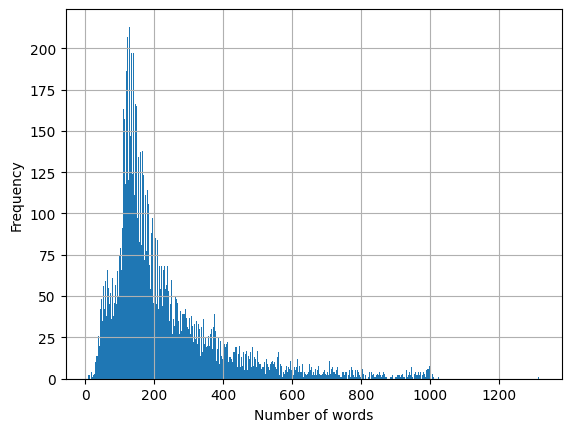

In [8]:
df['word_count'].hist(bins=500)
# distribution of review lengths is right-skewed and this is a very common and often natural distribution for text data

plt.xlabel("Number of words")
plt.ylabel("Frequency")

In [9]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment,word_count
33553,I really liked this Summerslam due to the look...,1,201
9427,Not many television shows appeal to quite as m...,1,354
199,The film quickly gets to a major chase scene w...,0,119
12447,Jane Austen would definitely approve of this o...,1,99
39489,Expectations were somewhat high for me when I ...,0,332


## Data preparation

In [10]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

In [11]:
class CustomDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len = 512):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text = str(self.texts[idx]) #The text is the sole input to the tokenizer for generating both the input_ids and the attention_mask.
    label = torch.tensor(self.labels[idx])
    encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length = self.max_len)

    return {
        'input_ids': encoding['input_ids'], #  text converted into numerical tokens (input IDs)
        'attention_mask': encoding['attention_mask'], # to distinguish real tokens from padding tokens
        'labels': label
    }

In [12]:
# prepare tokenizer and model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = 'distilbert-base-uncased'
device = "cuda"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
x = df['review'].tolist()

id2list = {1:'positive',0:'negative'}

y = df['sentiment'].tolist()

dataset = CustomDataset(x,y,tokenizer)
df.head()

,review,sentiment,word_count
33553,I really liked this Summerslam due to the look...,1,201
9427,Not many television shows appeal to quite as m...,1,354
199,The film quickly gets to a major chase scene w...,0,119
12447,Jane Austen would definitely approve of this o...,1,99
39489,Expectations were somewhat high for me when I ...,0,332


In [14]:
dataset[0].keys()

dict_keys(['input_ids', 'attention_mask', 'labels'])

In [15]:
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state = 42)

In [16]:
from sklearn.metrics import accuracy_score,f1_score
def compute_metrics(preds):
  labels = preds.label_ids
  preds = preds.predictions.argmax(-1) #preds.predictions is the raw model output — for binary classification, each example gets 2 numbers (a score for "negative" and a score for "positive")
  # .argmax(-1) picks whichever of those two numbers is bigger, converting scores into a single predicted class (0 or 1)
  f1 = f1_score(labels,preds,average="weighted")
  accuracy = accuracy_score(labels,preds)

  return {
      "accuracy" : accuracy,
      "f1":f1
  }

In [17]:
from transformers import TrainingArguments, Trainer

batch_size = 16
model_name = "distilbert_finetuned_sentiment"

args = TrainingArguments(
    output_dir = "output",
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    learning_rate = 2e-5,
    num_train_epochs = 1,
    weight_decay = 0.01,
    save_strategy = "epoch",
    eval_strategy = 'epoch'
)

In [18]:
trainer = Trainer(
    model=model,
    args = args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    compute_metrics = compute_metrics,
    processing_class =  tokenizer
    )

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.307130,0.221392,0.914500,0.914500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.3071298522949219, metrics={'train_runtime': 431.0424, 'train_samples_per_second': 18.56, 'train_steps_per_second': 1.16, 'total_flos': 1059739189248000.0, 'train_loss': 0.3071298522949219, 'epoch': 1.0})

In [21]:
text = "An absolute disaster of a script with zero redeeming qualities"
pipe = pipeline("text-classification", model="output/checkpoint-500")

pipe(text)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'LABEL_0', 'score': 0.9567443132400513}]

In [23]:
tok = AutoTokenizer.from_pretrained("output/checkpoint-500")
mod = AutoModelForSequenceClassification.from_pretrained("output/checkpoint-500")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [24]:
def get_prediction(text):
  input_ids = tok.encode(text, return_tensors='pt')
  output = mod(input_ids)

  preds = torch.nn.functional.softmax(output.logits, dim=-1)

  prob = torch.max(preds).item()

  idx = torch.argmax(preds).item()
  sentiment = id2list[idx]

  return {'sentiment':sentiment ,'prob':prob}

In [25]:
text="The score is haunting yet otherworldly—a perfect fit for the subject matter. This is not a mindless action film; instead, it is an intimate, philosophical drama that challenges the viewer."
get_prediction(text)

{'sentiment': 'positive', 'prob': 0.9738667607307434}

In [26]:
model_save_path = "./my_sentiment_model"
tok.save_pretrained(model_save_path)
mod.save_pretrained(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the tokenizer
loaded_tokenizer = AutoTokenizer.from_pretrained(model_save_path)

# Load the model
loaded_model = AutoModelForSequenceClassification.from_pretrained(model_save_path)

print(f"Model and tokenizer successfully loaded from: {model_save_path}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer successfully loaded from: ./my_sentiment_model


In [28]:
from transformers import pipeline

# Created a pipeline using the locally saved model
local_pipeline = pipeline("text-classification", model=model_save_path, tokenizer=model_save_path)

# Testing it with a new text
new_text = "This movie was utterly fantastic and I loved every minute of it!"
result = local_pipeline(new_text)

print(result)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'LABEL_1', 'score': 0.9770409464836121}]
